# Movie Review Sentiment Analysis - Teaching Edition

**Mission:** teach a computer to read a movie review and decide whether the critic
**liked** the film (positive) or **hated** it (negative).

**The big idea in one sentence:** we turn words into numbers, show the computer
thousands of reviews that already have answers, and let it learn the patterns.

---
### How this notebook is organised
Every new concept is explained with the same four questions, so you always know
what to look for:

1. **What is it?** - a plain-English definition.
2. **Why do we care?** - why this step matters for the project.
3. **Example** - a concrete illustration on our real data.
4. **Visualization** - a chart, because a picture is easier to understand than a number,
   followed by **how to read it**.

---
### The roadmap
| Stage | What we do |
|-------|------------|
| 1 | Load the data |
| 2 | Explore the data (EDA): balance, length, word clouds, top words, duplicates |
| 3 | Clean the text |
| 4 | Turn the answers into numbers (encode labels) |
| 5 | Split into a study set and an exam set |
| 6 | Turn the reviews into numbers (TF-IDF) |
| 7 | Train the model (Logistic Regression) |
| 8 | Grade the model (accuracy, confusion matrix, ROC) |
| 9 | Look inside the model (which words matter, where it fails) |
| 10 | Try it live on new reviews |


## Setup - get our tools out

Before any experiment we lay out our tools. Each library is a toolbox:

- **pandas** - holds the data as a table (like Excel inside Python).
- **numpy** - fast math on lists of numbers.
- **matplotlib / seaborn** - draw charts.
- **wordcloud** - draw word clouds.
- **scikit-learn (sklearn)** - the machine-learning recipes (vectorizer, model, metrics).


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import (
    TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS,
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42   # fixing the "seed" so we get the SAME results every run


## 1. Load the data

**What is it?** Reading the CSV file into a *DataFrame* - a table with rows
(one per review) and columns.

**Why do we care?** We need the data in memory before we can do anything, and we
should immediately confirm it loaded correctly and looks the way we expect.

**Example:** `.head()` shows the first five rows. Notice there are only **two
columns**: `review` (the text the critic wrote) and `sentiment` (the answer we
want to predict).


In [2]:
df = pd.read_csv("data/IMDB Dataset.csv")
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()


Rows: 50,000   Columns: 2


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


A quick health check every dataset deserves: the data types and whether anything
is missing.

**Why do we care about missing values?** A blank review has no words to learn
from, and many tools crash on missing cells. Good news below: there are **zero**
missing values, so we don't need to fill or drop anything.


In [3]:
print("Column data types:")
print(df.dtypes, "\n")
print("Missing values per column:")
print(df.isnull().sum())


Column data types:
review       str
sentiment    str
dtype: object 

Missing values per column:
review       0
sentiment    0
dtype: int64


## 2. Explore the data (EDA)

**EDA = Exploratory Data Analysis.** Before modelling, we get to know the data by
asking simple questions and drawing pictures.

**Why do we care?** A model is only as good as the data feeding it. EDA helps us:
- spot problems early (junk text, duplicates, imbalance),
- understand what the model will have to work with,
- and collect charts that explain the project to an audience.

Our EDA checklist:
1. **Class balance** - are positive and negative equally common?
2. **Review length** - how long is a typical review?
3. **Word clouds** - which words dominate each sentiment?
4. **Top words** - the exact most-frequent words per sentiment.
5. **Duplicates** - are any reviews repeated?


### 2.1 Class balance

**What is it?** The count of each answer - how many reviews are *positive* versus
*negative*.

**Why do we care?** If one class dominates, accuracy becomes misleading and the
model can get "lazy". Imagine 95% of reviews were positive: a model that blindly
guesses "positive" every time would be 95% accurate while having learned nothing.
With a **balanced** dataset, the naive baseline is only 50%, so any accuracy above
50% means the model is genuinely learning - and accuracy is a fair score to report.


sentiment
positive    25000
negative    25000
Name: count, dtype: int64 

Naive baseline (always guess the bigger class): 50.0%


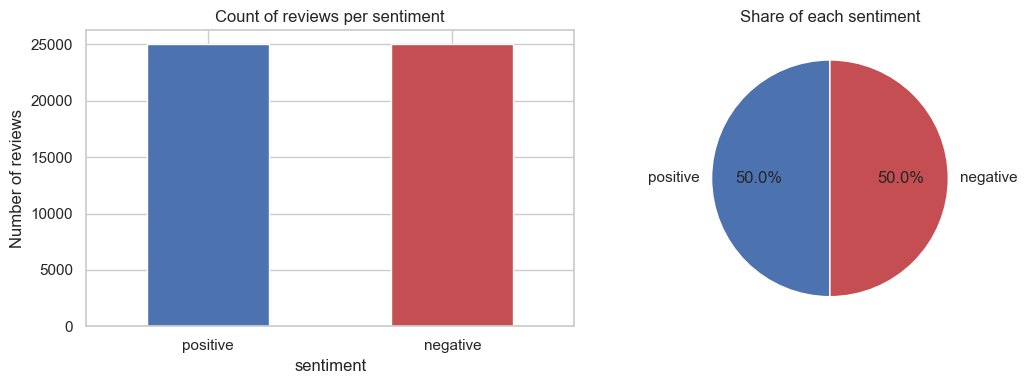

In [4]:
counts = df["sentiment"].value_counts()
print(counts, "\n")
print(f"Naive baseline (always guess the bigger class): {counts.max() / counts.sum():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts.plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax[0])
ax[0].set_title("Count of reviews per sentiment")
ax[0].set_ylabel("Number of reviews"); ax[0].tick_params(axis="x", rotation=0)
ax[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
          colors=["#4C72B0", "#C44E52"], startangle=90)
ax[1].set_title("Share of each sentiment")
plt.tight_layout(); plt.show()


**How to read it:** both bars are the same height and each slice is 50.0%. Our
dataset is **perfectly balanced** (25,000 each). That is the ideal case: accuracy
is trustworthy and we beat the 50% baseline only by really learning.


### 2.2 Read a few real reviews

**Why do we care?** Always look at raw data with your own eyes before trusting any
chart. Reading a couple of examples reveals the messy reality the model must
handle - including HTML fragments like `<br />` and tricky human language.


In [5]:
for label in ["positive", "negative"]:
    example = df[df.sentiment == label]["review"].iloc[0]
    print(f"===== A {label.upper()} review =====")
    print(example[:500], "...\n")


===== A POSITIVE review =====
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ ...

===== A NEGATIVE review =====
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in rea

### 2.3 How long are the reviews?

**What is it?** The number of words in each review.

**Why do we care?** Length tells us whether reviews are rich enough to contain real
opinion words, whether there are extreme outliers, and roughly how big our word
vocabulary might get. Very short reviews carry little signal; extremely long ones
can dominate if we are not careful.

**How to read the charts below:**
- The **histogram** shows the *shape* of the distribution. It is *right-skewed*:
  most reviews are short-to-medium, with a long tail of a few very long reviews.
- The **box plot by sentiment** lets us check a fair question: *do positive and
  negative reviews differ in length?* If the boxes line up, length alone is not a
  giveaway of sentiment - the actual words are what matter.


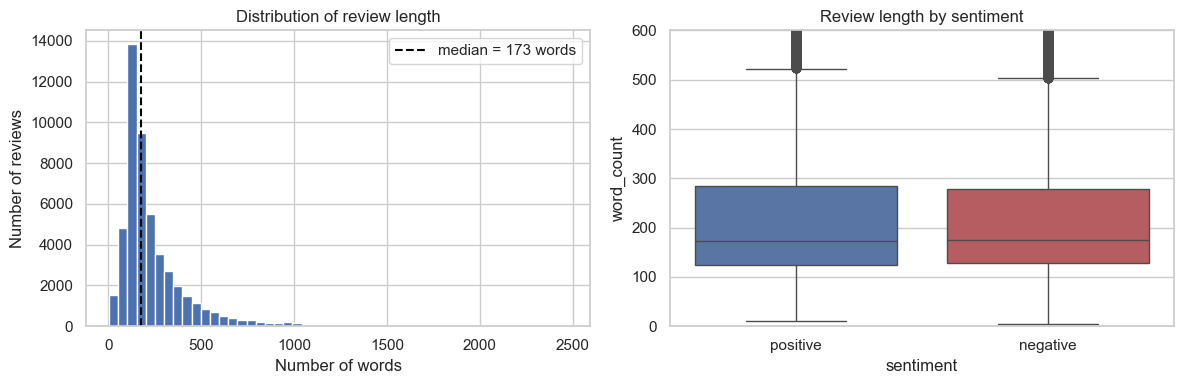

count    50000.0
mean       231.2
std        171.3
min          4.0
25%        126.0
50%        173.0
75%        280.0
max       2470.0
Name: word_count, dtype: float64


In [6]:
df["word_count"] = df["review"].str.split().str.len()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["word_count"], bins=50, color="#4C72B0")
ax[0].axvline(df["word_count"].median(), color="black", linestyle="--",
              label=f'median = {int(df["word_count"].median())} words')
ax[0].set_title("Distribution of review length")
ax[0].set_xlabel("Number of words"); ax[0].set_ylabel("Number of reviews"); ax[0].legend()

sns.boxplot(data=df, x="sentiment", y="word_count", hue="sentiment",
            palette=["#4C72B0", "#C44E52"], legend=False, ax=ax[1])
ax[1].set_title("Review length by sentiment"); ax[1].set_ylim(0, 600)
plt.tight_layout(); plt.show()

print(df["word_count"].describe().round(1))


**Interpretation:** the median review is about 120-130 words - plenty of room for
opinion words. Positive and negative reviews have almost the same length, which is
reassuring: the model cannot cheat by using length, it has to read the words.


### 2.4 Word clouds - which words dominate each sentiment?

**What is it?** A word cloud draws words at a size proportional to how often they
appear. Bigger word = more frequent.

**Why do we care?** It gives an instant, intuitive feel for the vocabulary of each
class and is a great sanity check: positive reviews *should* be full of words like
"great" and "love", negative ones full of "bad" and "worst". It also exposes data
problems - watch for the fragment **"br"** showing up, which is leftover from the
`<br />` HTML tags. Spotting that here is exactly what motivates the cleaning step
that comes next.


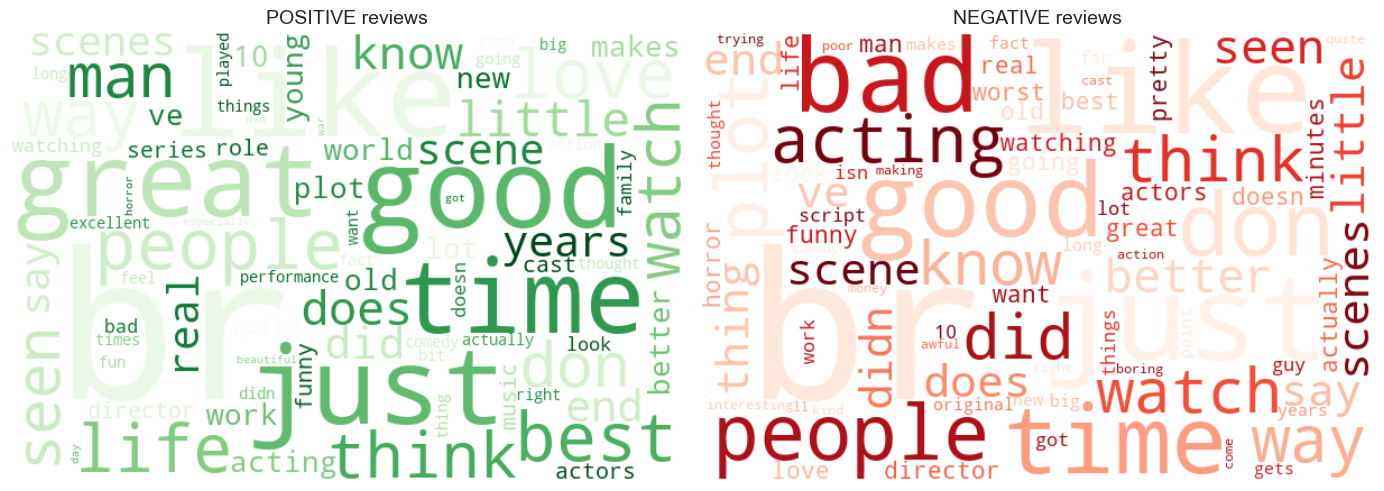

In [7]:
# Build word-frequency dictionaries (fast, and lets us control stop-words).
# We drop generic English words and a few domain words, but KEEP "br" on purpose
# so the leftover HTML junk is visible.
domain_stop = set(ENGLISH_STOP_WORDS) | {
    "movie", "film", "films", "movies", "one", "make", "see", "story",
    "character", "characters", "really", "even", "would", "much", "well",
}

def word_frequencies(texts, stopwords):
    cv = CountVectorizer(stop_words=list(stopwords))
    counts = cv.fit_transform(texts)
    totals = np.asarray(counts.sum(axis=0)).ravel()
    return dict(zip(cv.get_feature_names_out(), totals))

pos_freq = word_frequencies(df[df.sentiment == "positive"]["review"], domain_stop)
neg_freq = word_frequencies(df[df.sentiment == "negative"]["review"], domain_stop)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, freq, title, cmap in [
    (ax[0], pos_freq, "POSITIVE reviews", "Greens"),
    (ax[1], neg_freq, "NEGATIVE reviews", "Reds"),
]:
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap=cmap, max_words=80, random_state=RANDOM_STATE)
    wc.generate_from_frequencies(freq)
    a.imshow(wc, interpolation="bilinear"); a.axis("off"); a.set_title(title, fontsize=14)
plt.tight_layout(); plt.show()


**How to read it:** the positive cloud is dominated by words like *great, love,
best, well, life*; the negative cloud by *bad, worst, nothing, plot, boring*. This
confirms the labels make sense. You may also notice **"br"** floating in there -
that is HTML junk, our first concrete reason to clean the text.


### 2.5 Top words per sentiment (exact counts)

**What is it?** The word cloud is pretty but imprecise. Here we list the *exact*
most frequent words in each class as a bar chart.

**Why do we care?** Bars give precise, comparable numbers (a cloud's sizes are only
approximate). This is the chart to put on a slide when you want to *prove* which
words define each sentiment.


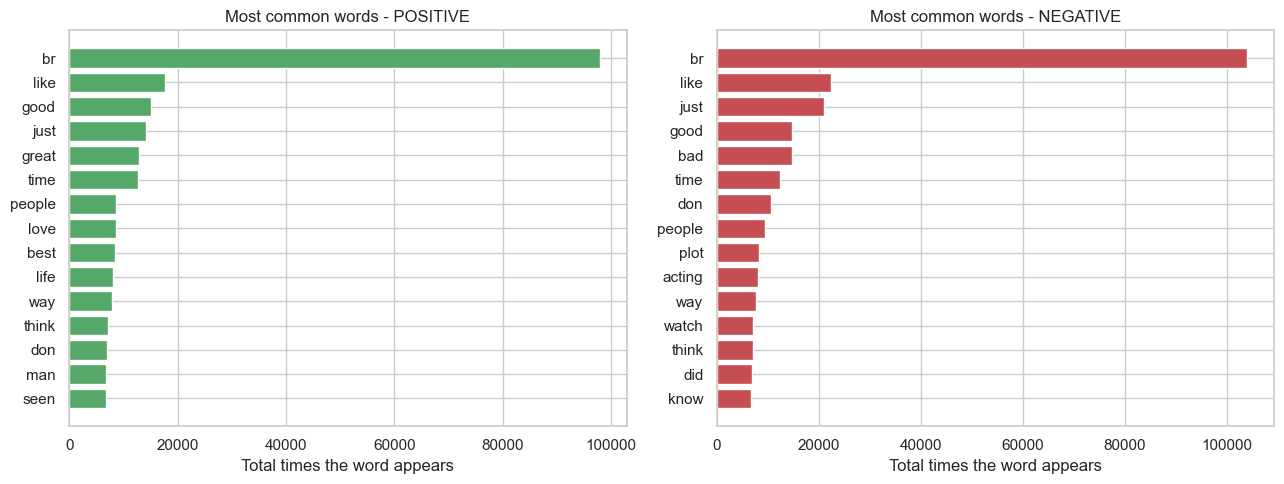

In [8]:
def top_words(freq, n=15):
    items = sorted(freq.items(), key=lambda kv: kv[1], reverse=True)[:n]
    words = [w for w, _ in items][::-1]
    vals = [c for _, c in items][::-1]
    return words, vals

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
w, v = top_words(pos_freq); ax[0].barh(w, v, color="#55A868"); ax[0].set_title("Most common words - POSITIVE")
w, v = top_words(neg_freq); ax[1].barh(w, v, color="#C44E52"); ax[1].set_title("Most common words - NEGATIVE")
for a in ax: a.set_xlabel("Total times the word appears")
plt.tight_layout(); plt.show()


**Interpretation:** notice some words (like *good*) appear a lot in *both* classes -
people write "not good" or "could be good but...". That is a preview of why simple
word-counting has limits and why two-word phrases (next steps) help.


### 2.6 Duplicate reviews

**What is it?** Rows whose review text is exactly identical to another row.

**Why do we care?** Duplicates are dangerous for two reasons:
1. **Data leakage** - if the *same* review lands in both the study set and the exam
   set, the model can score well by memorising rather than learning, and our final
   grade becomes dishonest.
2. **Over-counting** - a review repeated many times gets extra "votes" and can bias
   the model toward whatever it says.

**Example:** below we count the duplicates and print one repeated review so you can
see it is a genuine copy, not a coincidence.


Number of duplicate reviews: 418

Example of a repeated review (first 200 chars):
"Go Fish" garnered Rose Troche rightly or wrongly the reputation of a film maker with much promise.<br /><br />Its then hard to understand how she could turn out a movie made up of stereotypes that on ...


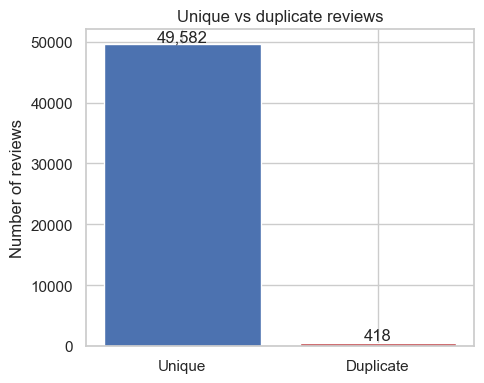

In [9]:
n_dupes = df.duplicated(subset="review").sum()
print(f"Number of duplicate reviews: {n_dupes}")

dup_mask = df.duplicated(subset="review", keep=False)
example_dup = df[dup_mask].sort_values("review")["review"].iloc[0]
print(f"\nExample of a repeated review (first 200 chars):\n{example_dup[:200]} ...")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Unique", "Duplicate"],
       [len(df) - n_dupes, n_dupes], color=["#4C72B0", "#C44E52"])
ax.set_title("Unique vs duplicate reviews"); ax.set_ylabel("Number of reviews")
for i, val in enumerate([len(df) - n_dupes, n_dupes]):
    ax.text(i, val, f"{val:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()


**How to read it:** only a few hundred of 50,000 are duplicates - a small fraction,
but we still remove them in the cleaning step for an honest experiment.


## 3. Clean the text

**What is it?** Standardising the raw text: removing HTML tags such as `<br />`,
squeezing repeated spaces, and (handled later by the vectorizer) lowercasing. We
also drop the duplicate rows we found above.

**Why do we care?** Computers take text literally. To a counting algorithm, `<br />`
looks like the "word" *br* - that was the junk we saw in the word cloud. If we leave
it in, *br* becomes one of the most common "words" and wastes a feature slot while
carrying zero opinion. The rule of thumb: **garbage in, garbage out.**

**What we deliberately keep:** the actual opinion words, and negation words like
*not*. We must not let *"not good"* collapse into *"good"*.

**Example:** the before/after below shows the same review with the HTML stripped out.


In [10]:
def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)   # remove HTML tags such as <br />
    text = re.sub(r"\s+", " ", text)     # squeeze repeated whitespace into one space
    return text.strip()

df["clean_review"] = df["review"].apply(clean_text)
df = df.drop_duplicates(subset="review").reset_index(drop=True)

print("BEFORE:\n", df["review"].iloc[0][:300])
print("\nAFTER:\n", df["clean_review"].iloc[0][:300])
print(f"\nRows remaining after removing duplicates: {len(df):,}")


BEFORE:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

AFTER:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this

Rows remaining after removing duplicates: 49,582


**Visualization - did cleaning actually remove the junk?** We count how many times
the token *br* appears before and after cleaning. A good clean drops it to zero.


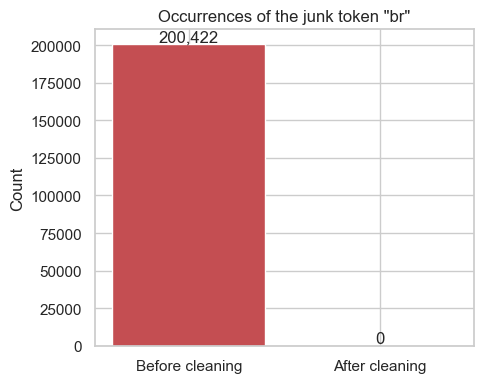

In [11]:
def count_token(texts, token):
    return texts.str.count(rf"\b{token}\b").sum()

before = count_token(df["review"], "br")
after = count_token(df["clean_review"], "br")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Before cleaning", "After cleaning"], [before, after], color=["#C44E52", "#55A868"])
ax.set_title('Occurrences of the junk token "br"'); ax.set_ylabel("Count")
for i, val in enumerate([before, after]):
    ax.text(i, val, f"{int(val):,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()


**How to read it:** the red bar (thousands of *br* tokens) collapses to zero. The
text is now clean enough to turn into features.


## 4. Turn the answers into numbers (encode labels)

**What is it?** Mapping the text answer to a number: **positive -> 1**,
**negative -> 0**.

**Why do we care?** Machine-learning models do arithmetic; they cannot add up the
word "positive". The model will learn to output a number near 1 for positive
reviews and near 0 for negative ones, so we line our answers up the same way.

**Example:** the new `label` column sits next to the original `sentiment` so you can
see the mapping at a glance.


In [12]:
df["label"] = (df["sentiment"] == "positive").astype(int)
df[["sentiment", "label"]].head(6)


,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1
5,positive,1


## 5. Split into a study set and an exam set

**What is it?** Randomly dividing the data into a **training set** (80%, the model
studies these *with* answers) and a **test set** (20%, a hidden exam the model never
sees while learning).

**Why do we care?** We want to know whether the model can handle *new* reviews, not
whether it memorised the ones it studied. Testing on data it already saw is like
grading a student on the exact questions they were given the answers to - the score
would be meaningless.

We also pass `stratify=y`, which keeps the 50/50 balance inside *both* halves so the
exam is as fair as the study material.

**Visualization:** the bars below confirm the split sizes and that both halves stay
balanced.


Training reviews: 39,665
Testing  reviews: 9,917


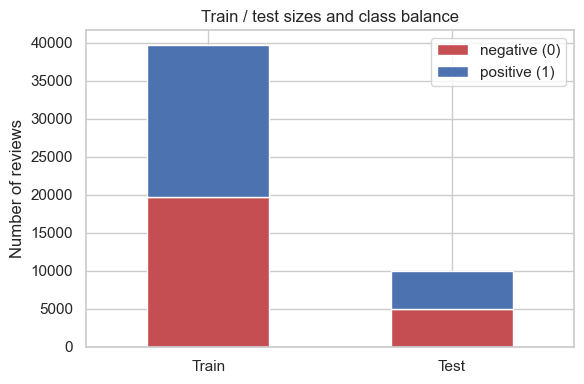

In [13]:
X = df["clean_review"]   # the input  (what the model reads)
y = df["label"]          # the answer (what we want it to predict)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
print(f"Training reviews: {len(X_train):,}")
print(f"Testing  reviews: {len(X_test):,}")

split_df = pd.DataFrame({
    "Train": y_train.value_counts().sort_index().values,
    "Test":  y_test.value_counts().sort_index().values,
}, index=["negative (0)", "positive (1)"])

ax = split_df.T.plot(kind="bar", stacked=True, color=["#C44E52", "#4C72B0"], figsize=(6, 4))
ax.set_title("Train / test sizes and class balance"); ax.set_ylabel("Number of reviews")
ax.tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()


**How to read it:** the training bar is four times taller than the test bar (80% vs
20%), and each bar is split evenly red/blue - balance preserved on both sides.


## 6. Turn the reviews into numbers (TF-IDF)

This is the conceptual heart of the project, so we build it up slowly.

### 6.1 First idea: Bag of Words

**What is it?** Imagine dumping every word of a review into a bag and just counting
how many times each word appears, ignoring order. Each review becomes a long row of
counts - one column per word in our vocabulary.

**Why do we care?** Models need every example as a fixed-length list of numbers. Bag
of Words is the simplest way to convert any review into exactly that.

**The catch:** common words like *movie* or *the* appear everywhere and dominate the
counts, even though they tell us nothing about sentiment.


**Example - Bag of Words on three tiny reviews.** We'll reuse these same three toy
reviews for TF-IDF next, so you can compare. Watch two things:

1. the **vocabulary map** - every unique word is handed a fixed **column number**,
2. the **count matrix** - each review becomes a row of counts in those columns.


In [14]:
toy = [
    "i loved this movie it was great",
    "i hated this movie it was boring",
    "what a great great film",
]

bow_vec = CountVectorizer()
bow_matrix = bow_vec.fit_transform(toy)

# (1) THE VOCABULARY MAP: which column number each word was given.
#     This dictionary is how the computer knows which number means which word.
print("Vocabulary map  (word -> column number):")
for word, col in sorted(bow_vec.vocabulary_.items(), key=lambda kv: kv[1]):
    print(f"   column {col:>2}   ->   {word}")

# (2) THE COUNT MATRIX: each review is now a row of numbers using those columns.
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vec.get_feature_names_out(),
    index=["review 1", "review 2", "review 3"],
)
print("\nBag-of-Words count matrix:")
print(bow_df)


Vocabulary map  (word -> column number):
   column  0   ->   boring
   column  1   ->   film
   column  2   ->   great
   column  3   ->   hated
   column  4   ->   it
   column  5   ->   loved
   column  6   ->   movie
   column  7   ->   this
   column  8   ->   was
   column  9   ->   what

Bag-of-Words count matrix:
          boring  film  great  hated  it  loved  movie  this  was  what
review 1       0     0      1      0   1      1      1     1    1     0
review 2       1     0      0      1   1      0      1     1    1     0
review 3       0     1      2      0   0      0      0     0    0     1


**Visualization - the count matrix as a heatmap.** Same numbers as above, but a
picture makes the pattern jump out.


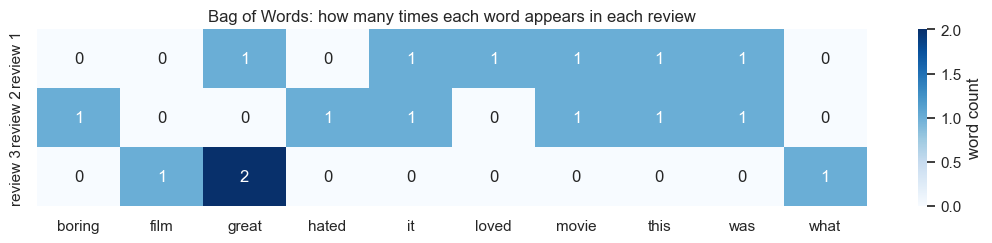

In [15]:
plt.figure(figsize=(11, 2.6))
sns.heatmap(bow_df, annot=True, cmap="Blues", cbar_kws={"label": "word count"})
plt.title("Bag of Words: how many times each word appears in each review")
plt.tight_layout(); plt.show()


**Visualization - one review as a "word-vector".** This is the key picture for your
question *"how do we know which number maps to which word?"* Review 3 is turned into
a list of numbers, and each slot is labelled with the word it stands for.


In [16]:
review3 = bow_df.loc["review 3"]
print('Review 3 text: "', toy[2], '"\n', sep="")
print('As a word-vector  ->  [', ", ".join(str(n) for n in review3.values), ']\n')
print("What each position means:")
for col, (word, count) in enumerate(review3.items()):
    bar = "#" * count
    print(f"   position {col:>2}  ({word:>6}) = {count}  {bar}")


Review 3 text: "what a great great film"

As a word-vector  ->  [ 0, 1, 2, 0, 0, 0, 0, 0, 0, 1 ]

What each position means:
   position  0  (boring) = 0  
   position  1  (  film) = 1  #
   position  2  ( great) = 2  ##
   position  3  ( hated) = 0  
   position  4  (    it) = 0  
   position  5  ( loved) = 0  
   position  6  ( movie) = 0  
   position  7  (  this) = 0  
   position  8  (   was) = 0  
   position  9  (  what) = 1  #


**How to read it:**
- The **vocabulary map** is the link between words and numbers. scikit-learn sorts the
  unique words alphabetically and numbers them: `boring` -> column 0, `film` -> column 1,
  `great` -> column 2, and so on. *The column position is the whole answer to "which
  number is which word."*
- Each **row** is a review rewritten as a vector of counts. Review 3 is
  `what a great great film`, so its `great` slot is **2** (it appears twice) and `film`
  is **1**; every word it does not use is **0**.
- The matrix is mostly **zeros** - any one review uses only a few of all possible words.
  With 50,000 real reviews the vocabulary is huge and the rows are almost entirely zeros;
  that is the "sparse" matrix we will meet in step 6.3.

So "turning words into numbers" is really two moves: **(1)** give every word a fixed column
(the vocabulary map), then **(2)** fill the row with counts. TF-IDF, next, keeps the exact
same columns but swaps the raw counts for smarter weights.


### 6.2 Better idea: TF-IDF

**What is it?** TF-IDF = *Term Frequency x Inverse Document Frequency*. It is Bag of
Words with a smarter weight for each word:

- **TF (term frequency):** a word counts for more if it appears many times *in this
  review*.
- **IDF (inverse document frequency):** a word counts for *less* if it appears in
  *almost every* review. Words that are everywhere (*movie*, *film*) are not
  distinctive, so their weight is shrunk.

**Result:** distinctive, meaningful words (*masterpiece*, *boring*) get **high**
scores; bland words that appear everywhere get **low** scores.

**Example:** let's compute TF-IDF by hand on three tiny "reviews" so you can see the
numbers, then visualise them as a heatmap.


          boring  film  great  hated    it  loved  movie  this   was  what
review 1    0.00  0.00   0.39   0.00  0.39   0.51   0.39  0.39  0.39  0.00
review 2    0.48  0.00   0.00   0.48  0.37   0.00   0.37  0.37  0.37  0.00
review 3    0.00  0.48   0.73   0.00  0.00   0.00   0.00  0.00  0.00  0.48 



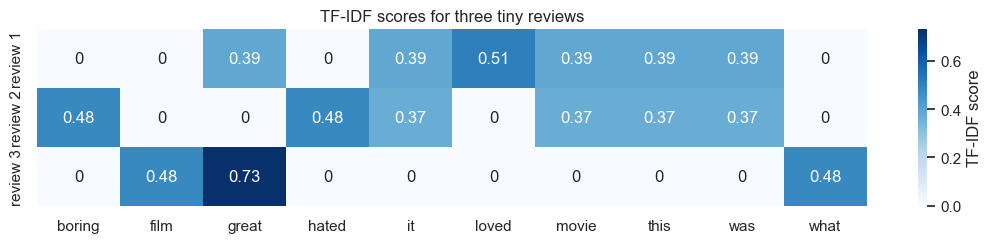

In [17]:
toy = [
    "i loved this movie it was great",
    "i hated this movie it was boring",
    "what a great great film",
]
toy_vec = TfidfVectorizer()
toy_matrix = toy_vec.fit_transform(toy)

toy_df = pd.DataFrame(
    toy_matrix.toarray().round(2),
    columns=toy_vec.get_feature_names_out(),
    index=["review 1", "review 2", "review 3"],
)
print(toy_df, "\n")

plt.figure(figsize=(11, 2.6))
sns.heatmap(toy_df, annot=True, cmap="Blues", cbar_kws={"label": "TF-IDF score"})
plt.title("TF-IDF scores for three tiny reviews")
plt.tight_layout(); plt.show()


**How to read the heatmap:** darker cell = higher TF-IDF = more important word for
that review.
- *this*, *it*, *was* appear in two of the three reviews, so their IDF is small and
  their cells are pale - they are not distinctive.
- *great* in **review 3** is the darkest cell: it appears **twice** there (high TF)
  and is fairly rare across the set, so it scores highest.
- *boring* lights up only **review 2**, instantly flagging it as the negative one.

That is the whole magic: TF-IDF automatically highlights the words that make a
review distinctive.


### 6.3 Apply TF-IDF to the real reviews

Now the real thing. The settings, explained:
- `stop_words="english"` - drop filler words (*the*, *and*, *of*).
- `ngram_range=(1, 2)` - learn single words **and** two-word phrases, so *"not good"*
  becomes its own feature. *(This is how the model can handle the nuance the mission
  warned about.)*
- `min_df=5` - ignore words seen in fewer than 5 reviews (usually typos).
- `max_features=20000` - keep only the 20,000 most useful words/phrases.

**Key habit:** we `fit` the vocabulary on the **training set only**, then `transform`
both sets. The test set must stay unseen, or the exam is rigged.


In [18]:
vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 2), min_df=5, max_features=20000,
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_vec.shape)
print(f"=> {X_train_vec.shape[0]:,} reviews, each described by "
      f"{X_train_vec.shape[1]:,} word-features.")

density = X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])
print(f"\nOnly {density:.3%} of the matrix is non-zero - it is 'sparse'.")
print("That makes sense: any single review uses only a tiny slice of the 20,000 words.")


Training matrix shape: (39665, 20000)
=> 39,665 reviews, each described by 20,000 word-features.

Only 0.464% of the matrix is non-zero - it is 'sparse'.
That makes sense: any single review uses only a tiny slice of the 20,000 words.


**Visualization - a single review as TF-IDF.** A review is now a row of 20,000
numbers, almost all zero. Below we pull out the handful of words that are *not* zero
for one review and show their scores - this is literally what the model sees.


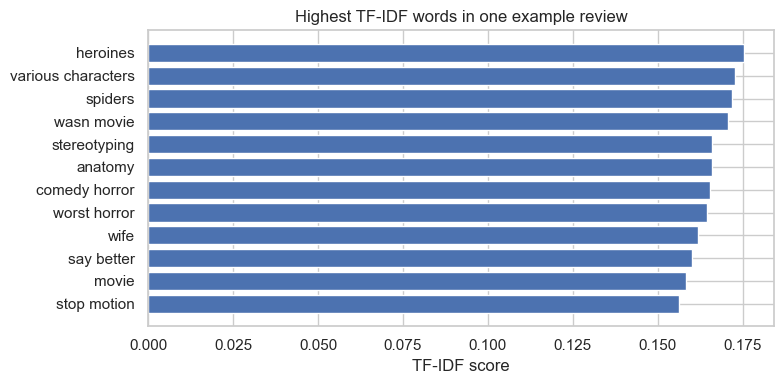

The model does not see sentences - it sees this list of weighted words.


In [19]:
row = X_test_vec[0].toarray().ravel()
feat = np.array(vectorizer.get_feature_names_out())
nz = row.nonzero()[0]
top = nz[np.argsort(row[nz])[-12:]]

plt.figure(figsize=(8, 4))
plt.barh(feat[top], row[top], color="#4C72B0")
plt.title("Highest TF-IDF words in one example review")
plt.xlabel("TF-IDF score"); plt.tight_layout(); plt.show()

print("The model does not see sentences - it sees this list of weighted words.")


## 7. Train the model (Logistic Regression)

**What is it?** Logistic Regression learns a **weight (a score)** for every
word-feature. To judge a review it multiplies each word's TF-IDF value by that
word's weight, adds them all up into a single number, then squashes that number into
a probability between 0 and 1 using the **sigmoid** function. Above 0.5 -> positive;
below -> negative.

**Why do we care / why this model?** It is:
- **simple and fast** - trains on 40,000 reviews in seconds,
- a **strong baseline** for text problems,
- and most importantly **interpretable** - the learned weights tell us exactly which
  words it thinks are positive or negative (we exploit this in Step 9).

**Visualization - the sigmoid.** This S-shaped curve is what turns the raw score into
a probability.


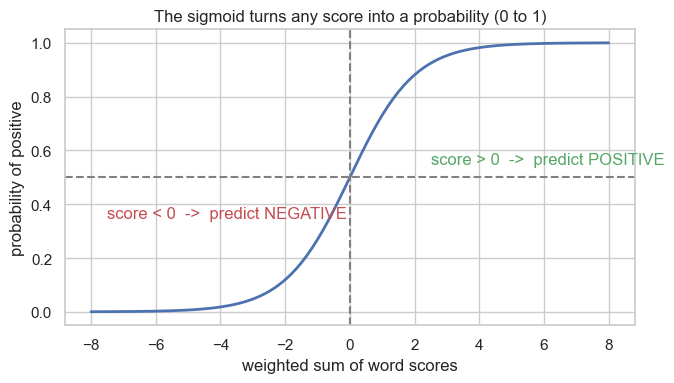

In [20]:
z = np.linspace(-8, 8, 200)
sigmoid = 1 / (1 + np.exp(-z))
plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid, color="#4C72B0", linewidth=2)
plt.axhline(0.5, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")
plt.text(2.5, 0.55, "score > 0  ->  predict POSITIVE", color="#55A868")
plt.text(-7.5, 0.35, "score < 0  ->  predict NEGATIVE", color="#C44E52")
plt.title("The sigmoid turns any score into a probability (0 to 1)")
plt.xlabel("weighted sum of word scores"); plt.ylabel("probability of positive")
plt.tight_layout(); plt.show()


**How to read it:** a very negative total score lands on the far left (probability
near 0 = confidently negative); a very positive total lands on the far right
(probability near 1 = confidently positive); a total of 0 sits at 0.5 - a coin flip.

Now the actual learning. `.fit()` reads all 40,000 training reviews and their
answers and finds the best weight for every word.


In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Save the words and their learned weights - we reuse these below.
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = model.coef_[0]
print("Model trained! It learned a weight for each of",
      f"{len(coefs):,} word-features.")


Model trained! It learned a weight for each of 20,000 word-features.


### Example: how the model scores one review

**Why do we care?** Seeing the weights in action on a single sentence makes the whole
"add up the word scores" idea concrete. Below we take one review and show which words
pushed it toward positive (green) or negative (red), and how the total lands.


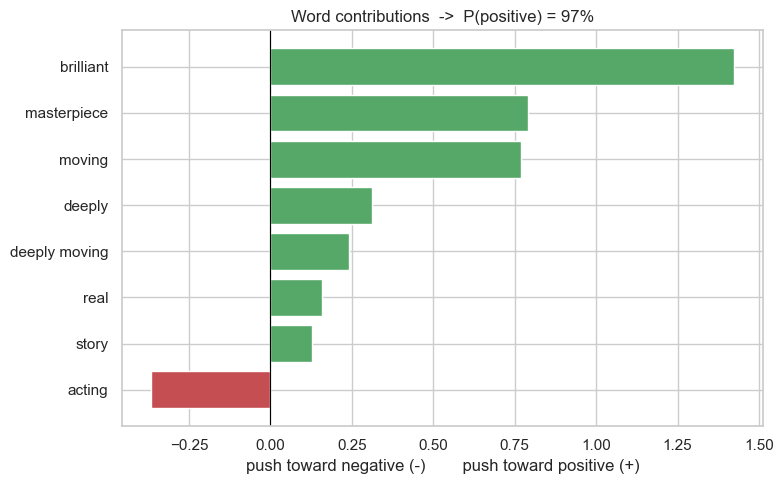

In [22]:
def explain_prediction(review):
    cleaned = clean_text(review)
    vec = vectorizer.transform([cleaned]).toarray().ravel()
    nz = vec.nonzero()[0]
    contributions = vec[nz] * coefs[nz]          # TF-IDF value x learned weight
    order = np.argsort(contributions)
    pick = np.concatenate([order[:6], order[-6:]])   # 6 most negative + 6 most positive
    words = feature_names[nz][pick]
    vals = contributions[pick]
    colors = ["#C44E52" if v < 0 else "#55A868" for v in vals]

    prob = model.predict_proba(vectorizer.transform([cleaned]))[0][1]
    plt.figure(figsize=(8, 5))
    plt.barh(words, vals, color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f'Word contributions  ->  P(positive) = {prob:.0%}')
    plt.xlabel("push toward negative (-)        push toward positive (+)")
    plt.tight_layout(); plt.show()

explain_prediction("The acting was brilliant and the story was deeply moving, a real masterpiece.")


**How to read it:** each green bar is a word voting "positive", each red bar a word
voting "negative", and the bar length is how strong that vote is. The model adds all
these votes; here the greens win, so it reports a high probability of positive.


## 8. Grade the model

**What is it?** We ask the trained model to predict the 10,000 **test** reviews it
has never seen, then compare its guesses to the real answers using several metrics.

**Why do we care?** A single number rarely tells the whole story, so we look at:
- **Accuracy** - the fraction it got right overall.
- **Precision** - when it says "positive", how often is it correct?
- **Recall** - of all the truly positive reviews, how many did it catch?
- **F1-score** - a single balance of precision and recall.


In [23]:
y_pred = model.predict(X_test_vec)
y_prob = model.predict_proba(X_test_vec)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on reviews it has NEVER seen: {accuracy:.1%}\n")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))


Accuracy on reviews it has NEVER seen: 89.7%

              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      4940
    positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



### 8.1 Confusion matrix

**What is it?** A 2x2 table of right vs wrong, broken down by class.

**Why do we care?** It shows *what kind* of mistakes happen, not just how many. Are we
worse at catching negative reviews, or positive ones? The diagonal is correct; the
off-diagonal cells are the errors.


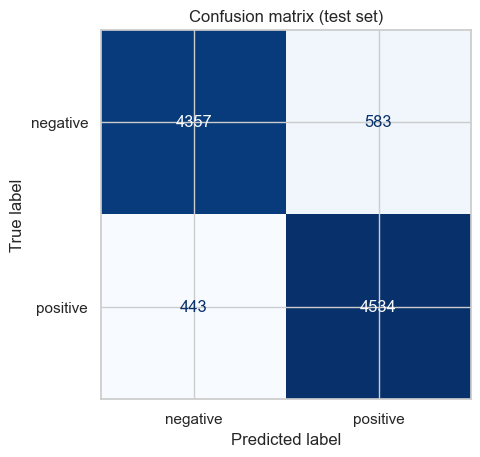

In [24]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(
    cmap="Blues", colorbar=False)
plt.title("Confusion matrix (test set)"); plt.show()


**How to read it:** top-left = negative reviews correctly called negative; bottom-right
= positive correctly called positive (these are the wins). Top-right = negative reviews
the model wrongly thought were positive; bottom-left = the opposite. The two error cells
are small and roughly equal, so the model is balanced - it is not biased toward one
answer.


### 8.2 ROC curve and AUC

**What is it?** So far we used a 0.5 cut-off. But we could be stricter or more lenient.
The **ROC curve** sweeps the cut-off across every value and plots how the true-positive
rate trades off against the false-positive rate. **AUC** (Area Under the Curve) squeezes
that whole curve into one number from 0.5 (random guessing) to 1.0 (perfect).

**Why do we care?** AUC measures how well the model *ranks* reviews regardless of where
we set the threshold - a more complete picture than accuracy alone.


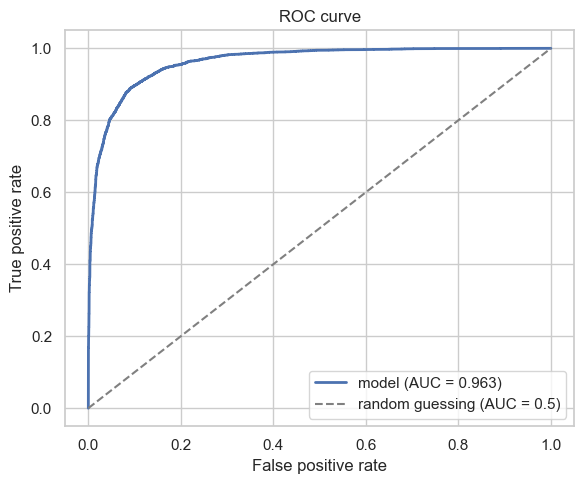

In [25]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4C72B0", linewidth=2, label=f"model (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="grey", linestyle="--", label="random guessing (AUC = 0.5)")
plt.title("ROC curve"); plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()


**How to read it:** the closer the blue curve hugs the top-left corner, the better.
The dashed diagonal is a coin flip. An AUC near 0.96 means that if you handed the model
one random positive and one random negative review, it would rank the positive one higher
about 96% of the time.


### 8.3 How confident is the model?

**What is it?** A histogram of the predicted probabilities for the test reviews.

**Why do we care?** It reveals the model's "personality". Lots of bars piled near 0 and
1 means the model is usually *decisive*; a big pile in the middle (around 0.5) would mean
it is often unsure - and reviews near 0.5 are exactly the hard, ambiguous ones.


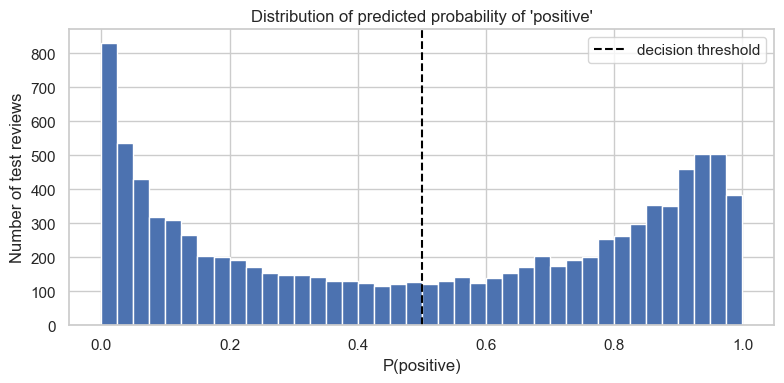

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(y_prob, bins=40, color="#4C72B0")
plt.axvline(0.5, color="black", linestyle="--", label="decision threshold")
plt.title("Distribution of predicted probability of 'positive'")
plt.xlabel("P(positive)"); plt.ylabel("Number of test reviews"); plt.legend()
plt.tight_layout(); plt.show()


**How to read it:** most reviews sit near 0 or 1 - the model is usually confident. The
relatively few reviews near 0.5 are the genuinely tricky ones (mixed or sarcastic), which
leads nicely into looking at its mistakes.


## 9. Look inside the model

This is the most insightful part - and the best material for a presentation.

### 9.1 Which words matter most?

**What is it?** Because the model is just a weight per word, we can list the words with
the biggest positive and biggest negative weights - literally what the model believes
makes a review good or bad.

**Why do we care?** It builds trust (the model is not a black box), and it is striking
that *nobody programmed these rules* - the model discovered them purely from examples.


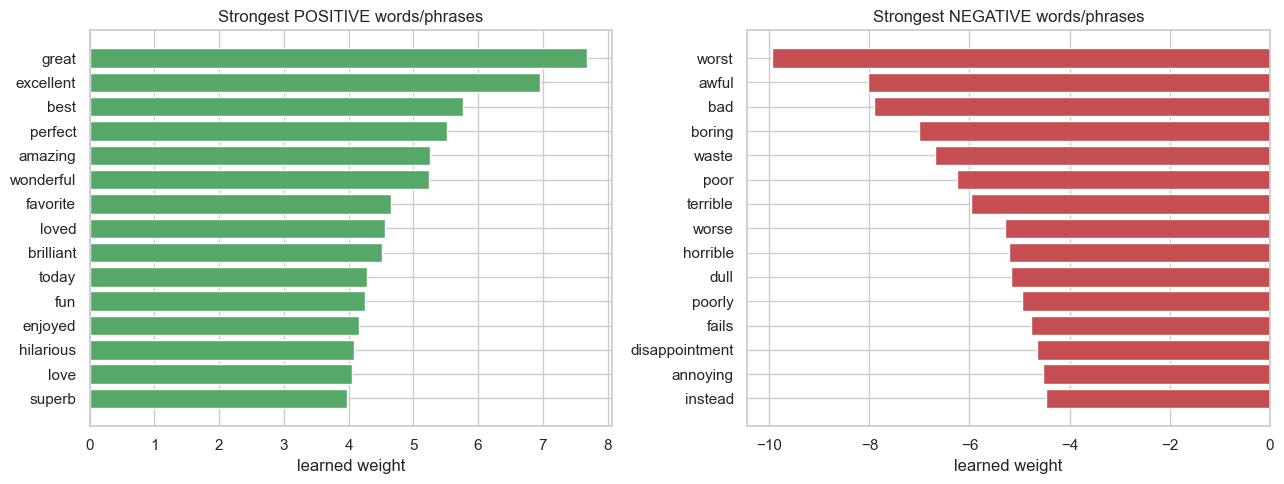

In [27]:
top_pos = np.argsort(coefs)[-15:][::-1]
top_neg = np.argsort(coefs)[:15]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].barh(feature_names[top_pos][::-1], coefs[top_pos][::-1], color="#55A868")
ax[0].set_title("Strongest POSITIVE words/phrases"); ax[0].set_xlabel("learned weight")
ax[1].barh(feature_names[top_neg][::-1], coefs[top_neg][::-1], color="#C44E52")
ax[1].set_title("Strongest NEGATIVE words/phrases"); ax[1].set_xlabel("learned weight")
plt.tight_layout(); plt.show()


**How to read it:** longer bar = stronger opinion. The model learned, with no rules
given, that *great*, *excellent* and *perfect* are positive while *worst*, *awful* and
*boring* are negative. Because we allowed two-word phrases, you may also spot signals
like *the worst* or *waste of* - evidence it picked up phrases, not just lone words.


### 9.2 The "dark / heavy" nuance

**Why do we care?** The mission warned that in film criticism, words like *dark*,
*heavy* or *twisted* can be **compliments**. Let's check what weight the model gave them.
This is a great discussion point about how language is genuinely ambiguous and where a
simple model reaches its limits.


In [28]:
print("Learned weight for some context-dependent words")
print("(positive number leans positive, negative leans negative):\n")
for word in ["dark", "heavy", "twisted", "disturbing", "brutal", "slow", "predictable"]:
    idx = np.where(feature_names == word)[0]
    verdict = f"{coefs[idx[0]]:+.2f}" if len(idx) else "(not in vocabulary)"
    print(f"  {word:<12} {verdict}")


Learned weight for some context-dependent words
(positive number leans positive, negative leans negative):

  dark         +0.98
  heavy        -0.61
  twisted      +0.63
  disturbing   -0.01
  brutal       +1.04
  slow         -1.30
  predictable  -3.01


**Interpretation:** words like *dark*, *brutal* and *twisted* actually come out slightly
**positive** - in film reviews they often praise an intense, gripping film. Meanwhile
*boring*, *slow* and *predictable* are firmly negative. The model captured a real piece of
film-critic culture straight from the data.


### 9.3 Where does it fail?

**What is it?** The test reviews the model got **most confidently wrong** - it was sure,
and still mistaken.

**Why do we care?** Studying failures is how you understand a model's blind spots. These
are usually sarcasm, mixed opinions, or reviews that praise the plot while panning the
film. It is honest to show these in a presentation - no model is perfect.


In [29]:
test_df = pd.DataFrame({"review": X_test.values, "true": y_test.values,
                        "pred": y_pred, "prob_pos": y_prob})
wrong = test_df[test_df.true != test_df.pred].copy()
wrong["confidence"] = np.where(wrong.pred == 1, wrong.prob_pos, 1 - wrong.prob_pos)
worst = wrong.sort_values("confidence", ascending=False).head(3)

label = {0: "negative", 1: "positive"}
for _, r in worst.iterrows():
    print(f"TRUE: {label[r.true]}  |  MODEL SAID: {label[r.pred]} "
          f"(confidence {r.confidence:.0%})")
    print(r.review[:350], "...\n")


TRUE: positive  |  MODEL SAID: negative (confidence 99%)
This is simply the funniest movie I've seen in a long time. The bad acting, bad script, bad scenery, bad costumes, bad camera work and bad special effects are so stupid that you find yourself reeling with laughter. So it's not gonna win an Oscar but if you've got beer and friends round then you can't go wrong. ...

TRUE: positive  |  MODEL SAID: negative (confidence 98%)
**SPOILERS AHEAD** It is really unfortunate that a movie so well produced turns out to be such a disappointment. I thought this was full of (silly) clichés and that it basically tried to hard. To the (American) guys out there: how many of you spend your time jumping on your girlfriend's bed and making monkey sounds? To the (married) girls: how many ...

TRUE: positive  |  MODEL SAID: negative (confidence 97%)
"Comanche Moon" had everything going for it. For starters, Simon Wincer's back, a man who's name is synonymous with high-quality TV westerns. Unfortunately,

**Interpretation:** read these and you will usually find sarcasm or a twist - e.g. a
review that lists everything that *should* have been good before concluding it was awful.
Word-counting cannot feel sarcasm, which is exactly the kind of problem more advanced,
context-aware models are built to tackle.


## 10. Try it live

**What is it?** A function that takes **any** review you type, runs it through the exact
same pipeline (clean -> TF-IDF -> model), and returns a verdict with a confidence score
and the contribution chart from Step 7.

**Why do we care?** This is the payoff and a perfect live demo - ask the audience for a
movie opinion and predict it on the spot. The third built-in example uses the tricky
*"dark and heavy"* phrasing on purpose.


Review: "This movie was an absolute masterpiece. I loved every minute!"
Prediction: POSITIVE   (confidence: 88%)

Review: "What a boring, predictable waste of time. I want my money back."
Prediction: NEGATIVE   (confidence: 100%)

Review: "It was dark and heavy, but in the best possible way -- stunning."
Prediction: POSITIVE   (confidence: 88%)



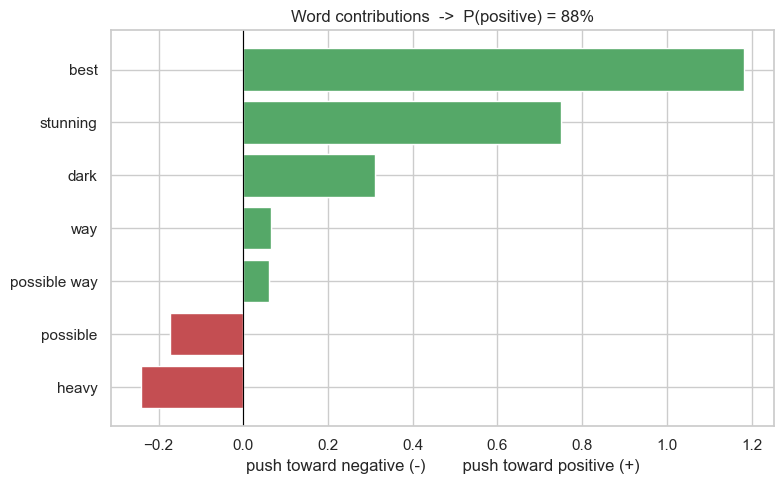

In [30]:
def predict_sentiment(review, show_chart=False):
    cleaned = clean_text(review)
    prob = model.predict_proba(vectorizer.transform([cleaned]))[0][1]
    verdict = "POSITIVE" if prob >= 0.5 else "NEGATIVE"
    confidence = max(prob, 1 - prob)
    print(f'Review: "{review}"')
    print(f"Prediction: {verdict}   (confidence: {confidence:.0%})\n")
    if show_chart:
        explain_prediction(review)

predict_sentiment("This movie was an absolute masterpiece. I loved every minute!")
predict_sentiment("What a boring, predictable waste of time. I want my money back.")
predict_sentiment("It was dark and heavy, but in the best possible way -- stunning.", show_chart=True)


Review: "Type your own movie review here!"
Prediction: POSITIVE   (confidence: 51%)



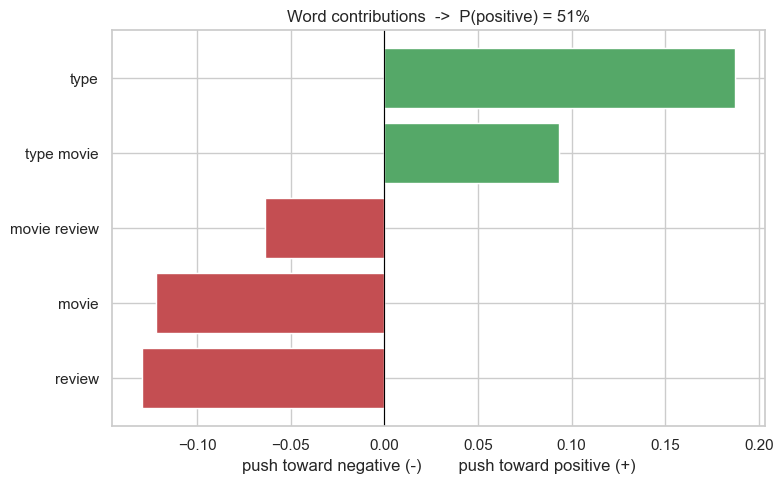

In [31]:
# Your turn: change the text and run this cell.
predict_sentiment("Type your own movie review here!", show_chart=True)


## Recap - what we built and learned

| Step | What it taught us |
|------|-------------------|
| Explore (EDA) | The data is balanced, clean-ish, with HTML junk and a few duplicates to fix. |
| Clean | Remove noise (`<br />`) so features carry real meaning. |
| Encode | Models need numbers, so positive -> 1, negative -> 0. |
| Split | Hide 20% for an honest final exam. |
| TF-IDF | Turn each review into weighted word-scores that highlight distinctive words. |
| Train | Logistic Regression learns a score per word and adds them up. |
| Evaluate | About 90% accurate on unseen reviews, with a high AUC and balanced errors. |
| Interpret | The model learned sensible word meanings on its own - including film nuance. |

### Talking points for the presentation
- "The computer learned from **examples, not rules** - that is machine learning."
- "TF-IDF is the trick that turns **words into numbers** a model can use."
- "The model is **interpretable**: we can list the exact words it finds positive or negative."
- "Its hardest cases are **sarcasm and double meanings** like *dark* - a great reason to
  explore more advanced models next."

### If you want to go further
- Try a different model (e.g. `MultinomialNB`) and compare accuracy.
- Widen to three-word phrases with `ngram_range=(1, 3)`.
- Read more of the confidently-wrong reviews and group the failure types.

**Well done - you trained a real text classifier and can explain every single step.**
